# Setup Inicial

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('dataset_evasao_escolar_500_registros_com_valores_faltantes.csv')

In [3]:
def generate_gaussian_distribution(series, x_label, y_label, title):
    sns.histplot(series, bins=20, kde=True)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)
    plt.show()

In [4]:
def get_invalid_numbers(series):
    numeric = pd.to_numeric(series, errors="coerce")
    invalids = series[numeric.isna() & series.notna()]
    return invalids

# Diagnóstico da Qualidade dos Dados

#### a) Verifique a existência de valores ausentes, apresentando a quantidade e o percentual de valores ausentes em cada atributo;

In [5]:
null_summary = pd.DataFrame({
    "Qtd. Ausentes": df.isna().sum(),
    "% Ausentes": df.isna().mean() * 100
})

print(null_summary)

                       Qtd. Ausentes  % Ausentes
id_aluno                           0         0.0
idade                             12         2.4
escola_origem                      0         0.0
municipio_residencia              12         2.4
estado_residencia                  0         0.0
renda_familiar_mensal             22         4.4
pessoas_domicilio                  0         0.0
acesso_internet                   14         2.8
trabalha                           0         0.0
turno                              0         0.0
horas_estudo_semana               17         3.4
frequencia_percentual             18         3.6
nota_media                        16         3.2
reprovacoes                        0         0.0
data_matricula                    12         2.4
situacao                           0         0.0
motivo_evasao                    398        79.6


#### b) Verifique a existência de duplicidades;

In [6]:
print(df.describe()["id_aluno"])

count       500
unique      470
top       A0322
freq          2
Name: id_aluno, dtype: object


Há 30 ids repetidos, sendo eles: 

In [7]:
ids_repetidos = df.loc[
    df["id_aluno"].duplicated(), 'id_aluno'
].unique().tolist()

print(ids_repetidos)

['A0326', 'A0311', 'A0120', 'A0093', 'A0127', 'A0441', 'A0087', 'A0256', 'A0013', 'A0100', 'A0429', 'A0151', 'A0353', 'A0126', 'A0021', 'A0230', 'A0440', 'A0272', 'A0342', 'A0397', 'A0169', 'A0052', 'A0436', 'A0136', 'A0199', 'A0322', 'A0233', 'A0467', 'A0082', 'A0376']


#### c) Verifique a existência de Inconsistências, identificando em seu relatório, pelo menos, três atributos que apresentem diferentes formas de representar a mesma informação. Exemplo: Maceio, maceio, MACEIÓ, Maceió.

| Problema | Atributo | Explicação |
|---|---|---|
| **Consistência** | **Idade** | Duas linhas fogem do padrão: `19 anos` e `vinte`. |
| **Consistência** | **Escola Origem** | 7 valores únicos, embora existam apenas 2 classificações. |
| **Consistência** | **Município Residência** | 9 valores únicos, mas apenas 6 municípios. |
| **Consistência** | **Pessoas Domicílio** | Um valor está escrito por extenso. |
| **Consistência** | **Acesso Internet** | 6 valores únicos para apenas `Sim` ou `Não`. |
| **Consistência** | **Trabalha** | Existem diferentes representações da mesma classificação. |
| **Consistência** | **Horas Estudo Semana** | Alguns valores incluem a palavra `horas`. |
| **Consistência** | **Frequência Percentual** | Diferentes formatos de representação da porcentagem. |
| **Consistência** | **Nota Média** | Um valor está escrito por extenso. |
| **Consistência** | **Reprovações** | Um valor está escrito por extenso. |
| **Consistência** | **Data Matrícula** | Mistura `2026-02-17` e `02/17/2026`. |
| **Consistência** | **Situação** | `Evadido` e `Evadiu` representam a mesma situação. |


#### d) Identifique valores inválidos ou suspeitos, que não estejam de acordo com o domínio esperado. Exemplos: idade = -3, frequência = 120, nota = 15.

| Problema | Atributo | Explicação |
|---|---|---|
| **Validade** | **Idade** | Uma linha apresenta o valor `145`. |
| **Validade** | **Renda Familiar Mensal** | Uma linha apresenta um valor negativo. |
| **Validade** | **Frequência Percentual** | Há linhas com valores acima de `100` e uma linha com valor negativo. |
| **Validade** | **Nota Média** | Há valores acima de `10` e um valor negativo. |

# Limpeza e Transformação

#### a) Correção/remoção de duplicidades – apresente um relatório informando a quantidade que havia antes, a quantidade removida e o total de registros após a operação de limpeza.

In [8]:
df = df.drop_duplicates()

print(df.describe()["id_aluno"])

count       470
unique      470
top       A0275
freq          1
Name: id_aluno, dtype: object


Com o código acima, removemos as 30 duplicatas identificadas anteriormente.

#### b) Realize a padronização de atributos categóricos que possuam diferenças de letras maiúsculas/minúsculas, espaços, acentuação, abreviações ou representações diferentes.

In [9]:
col = df["escola_origem"].astype("string").str.strip().str.upper()

df["escola_origem"] = col.replace({
    "PUB.": "Pública",
    "PUBLICA": "Pública",
    "ESCOLA PÚBLICA": "Pública",
    "ESCOLA PRIVADA": "Privada",
    "PARTICULAR": "Privada",
    "PÚBLICA": "Pública",
    "PRIVADA": "Privada"
})

In [10]:
df["escola_origem"].unique()

<StringArray>
['Pública', 'Privada']
Length: 2, dtype: string

In [11]:
col = df["municipio_residencia"].astype("string").str.strip().str.upper()

df["municipio_residencia"] = col.replace({
    "MACEIO": "Maceió",
    "MACEIÓ": "Maceió",
    "MARECHAL DEODORO": "Marechal Deodoro",
    "ARAPIRACA": "Arapiraca",
    "PALMEIRA DOS INDIOS": "Palmeira dos Índios",
    "PALMEIRA DOS ÍNDIOS": "Palmeira dos Índios",
    "RIO LARGO": "Rio Largo",
    "UNIAO DOS PALMARES": "União dos Palmares",
    "UNIÃO DOS PALMARES": "União dos Palmares"
})

In [12]:
df["municipio_residencia"].unique()

<StringArray>
[             'Maceió',  'União dos Palmares',    'Marechal Deodoro',
           'Arapiraca', 'Palmeira dos Índios',           'Rio Largo',
                  <NA>]
Length: 7, dtype: string

In [13]:
col = df["acesso_internet"].astype("string").str.strip().str.upper()

df["acesso_internet"] = col.replace({
    "1": "Sim",
    "S": "Sim",
    "SIM": "Sim",
    "YES": "Sim",
    "NÃO": "Não",
    "N": "Não",
    "NO": "Não"
})

In [14]:
df["acesso_internet"].unique()

<StringArray>
['Sim', <NA>, 'Não']
Length: 3, dtype: string

In [15]:
col = df["turno"].astype("string").str.strip().str.upper()

df["turno"] = col.replace({
    "MANHÃ": "Manhã",
    "M": "Manhã",
    "MANHA": "Manhã",
    "TARDE": "Tarde",
    "T": "Tarde",
    "NOITE": "Noite",
    "N": "Noite"
})

In [16]:
df["turno"].unique()

<StringArray>
['Manhã', 'Tarde', 'Noite']
Length: 3, dtype: string

In [17]:
col = df["situacao"].astype("string").str.strip().str.upper()

df["situacao"] = col.replace({
    "ATIVO": "Ativo",
    "EVADIDO": "Evadido",
    "EVADIU": "Evadido",
    "DESISTENTE": "Evadido",
    "MATRICULADO": "Matriculado",
})

In [18]:
df["situacao"].unique()

<StringArray>
['Ativo', 'Evadido', 'Matriculado']
Length: 3, dtype: string

#### c) Verifique e corrija atributos numéricos armazenados como texto.

In [19]:
df["idade"] = df["idade"].replace({
    "vinte": "20",
    "20 anos": "20",
    "19 anos": "19"
})
df["idade"] = pd.to_numeric(df["idade"], errors="coerce")
df = df.dropna(subset=["idade"])
df = df[(df["idade"] > 0) & (df["idade"] < 100)]
df["idade"] = df["idade"].astype(int)

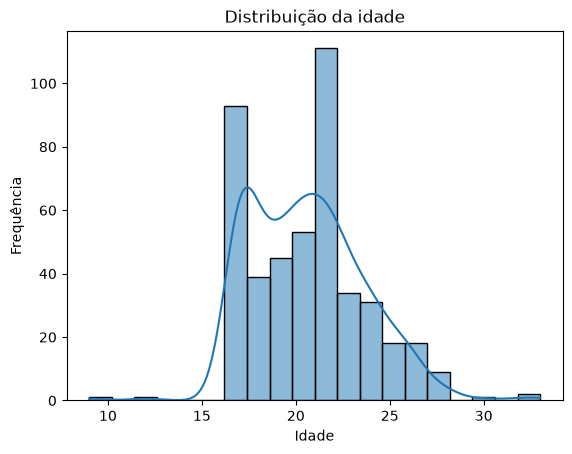

In [20]:
generate_gaussian_distribution(df["idade"], "Idade", "Frequência", "Distribuição da idade")

Como não são valores bem distribuídos, e nem a presença de outliers, optei por remover a os valores nulos.

In [21]:
df["renda_familiar_mensal"] = (
    df["renda_familiar_mensal"]
        .str.replace("R$", "", regex=False)
        .str.replace(".", "", regex=False)
        .str.replace(",", ".", regex=False)
        .str.strip()
)

df["renda_familiar_mensal"] = pd.to_numeric(df["renda_familiar_mensal"], errors="coerce")

In [22]:
len(df["pessoas_domicilio"].unique())

12

In [23]:
df["pessoas_domicilio"] = df["pessoas_domicilio"].replace({
    "quatro": "4",
})

df["pessoas_domicilio"] = pd.to_numeric(df["pessoas_domicilio"], errors="coerce")

In [24]:
horas_estudo_semana = (
    df["horas_estudo_semana"]
        .str.replace("horas", "", regex=False)
        .str.replace("h", "", regex=False)
        .str.strip()
)

horas_estudo_semana = pd.to_numeric(df["horas_estudo_semana"], errors="coerce")

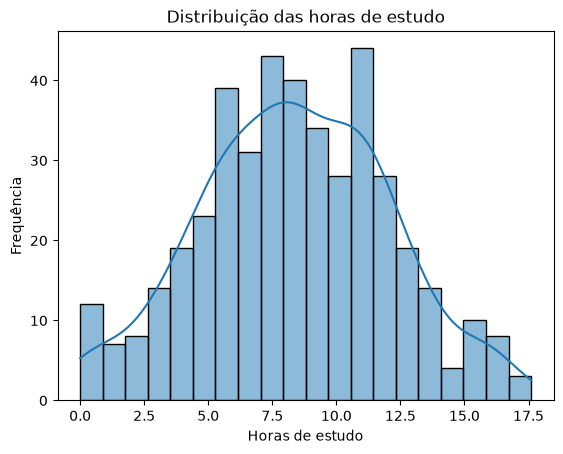

In [25]:
generate_gaussian_distribution(horas_estudo_semana, "Horas de estudo", "Frequência", "Distribuição das horas de estudo")

Como os dados são numéricos e bem distribuídos, optarei por tratar os valores nulos de horas_estudo com uma inputação estatística, aplicando a média.

In [26]:
round(horas_estudo_semana.mean(), 1)

np.float64(8.4)

In [27]:
df["horas_estudo_semana"] = (
    df["horas_estudo_semana"]
        .str.replace("horas", "", regex=False)
        .str.replace("h", "", regex=False)
        .str.replace(",", ".", regex=False)
        .str.strip()
)

df["horas_estudo_semana"] = df["horas_estudo_semana"].fillna(8.4)

df["horas_estudo_semana"] = pd.to_numeric(df["horas_estudo_semana"], errors="coerce")

In [28]:
frequencia_percentual = df["frequencia_percentual"].replace({
    "oitenta": "80",
    "85%": "85",
})

frequencia_percentual = pd.to_numeric(df["idade"], errors="coerce")

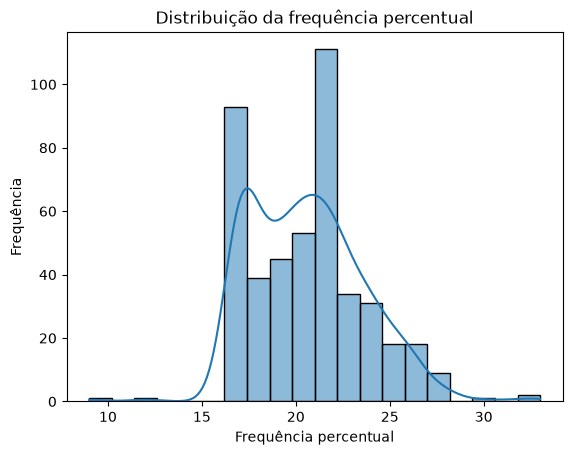

In [29]:
generate_gaussian_distribution(frequencia_percentual, "Frequência percentual", "Frequência", "Distribuição da frequência percentual")

In [30]:
frequencia_percentual.median()

np.float64(20.0)

Apesar do percentual de nulos para essa coluna ser de 3.6%, eu não gostaria de descartar os valores nulos, prefiro optar por uma imputação estatística, pois das 18 linhas com valores nulos para frequência percentual, 4 delas possuem evasão justificada, o que eu acho interessante para a análise. A frequência percentual não é bem distribuída, portanto, estarei aplicando a mediana nos valores nulos.

In [31]:
df["frequencia_percentual"] = df["frequencia_percentual"].replace({
    "oitenta": "80",
    "85%": "85",
})

df["frequencia_percentual"] = df["frequencia_percentual"].fillna(20)

df["frequencia_percentual"] = pd.to_numeric(df["horas_estudo_semana"], errors="coerce")

In [33]:
get_invalid_numbers(df["nota_media"])

62     dez
450    8,5
Name: nota_media, dtype: str

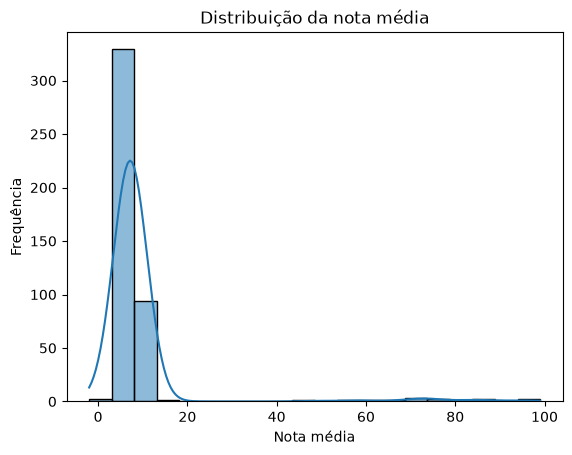

In [35]:
nota_media = df["nota_media"].replace({
    "dez": "10",
    "8,5": "8.5"
})

nota_media = pd.to_numeric(nota_media, errors="coerce")

generate_gaussian_distribution(nota_media, "Nota média", "Frequência", "Distribuição da nota média")

In [38]:
round(nota_media.median(), 1)

np.float64(7.2)

A nota média é bem distribuída, porém tem alguns outliers acima de 10, provavelmente por